<a href="https://colab.research.google.com/github/Twishha-Soni/Telecom-Customer-Churn-Prediction/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



> With train test split earlier before EDA.



In [1]:
import pandas as pd

# Load the raw dataset (adjust path if yours differs — this is the standard
# Kaggle filename for this dataset)
df = pd.read_csv('https://raw.githubusercontent.com/Twishha-Soni/Telecom-Customer-Churn-Prediction/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [2]:
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [3]:
from sklearn.model_selection import train_test_split

# Stratify directly on the Churn label — no artificial binning needed,
# since Churn is already categorical (unlike median_house_value in the book)
train_set, test_set = train_test_split(
    df, test_size=0.2, stratify=df["Churn"], random_state=42
)

print("Full dataset churn ratio:")
print(df["Churn"].value_counts(normalize=True))

print("\nTrain set churn ratio:")
print(train_set["Churn"].value_counts(normalize=True))

print("\nTest set churn ratio:")
print(test_set["Churn"].value_counts(normalize=True))

Full dataset churn ratio:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Train set churn ratio:
Churn
No     0.734647
Yes    0.265353
Name: proportion, dtype: float64

Test set churn ratio:
Churn
No     0.734564
Yes    0.265436
Name: proportion, dtype: float64


In [4]:
# Work on a copy — never mutate train_set itself, and test_set stays untouched
explore = train_set.copy()

# --- Temporary fix for visualization only (NOT the pipeline fix) ---
# TotalCharges is stored as a string with blank entries for zero-tenure
# customers. We can't plot or correlate a string column, so we do a
# throwaway numeric conversion here, purely to explore. This is the same
# spirit as the temporary binary encoding of Churn you did for the L1
# correlation step — exploratory only, not the real fix.
# The REAL fix (SimpleImputer, fit only on train, applied consistently to
# test/serving data) happens formally in step 5. Don't treat this as done.
explore["TotalCharges"] = pd.to_numeric(explore["TotalCharges"], errors="coerce")

print(f"Blank TotalCharges entries (now NaN): {explore['TotalCharges'].isna().sum()}")

Blank TotalCharges entries (now NaN): 8


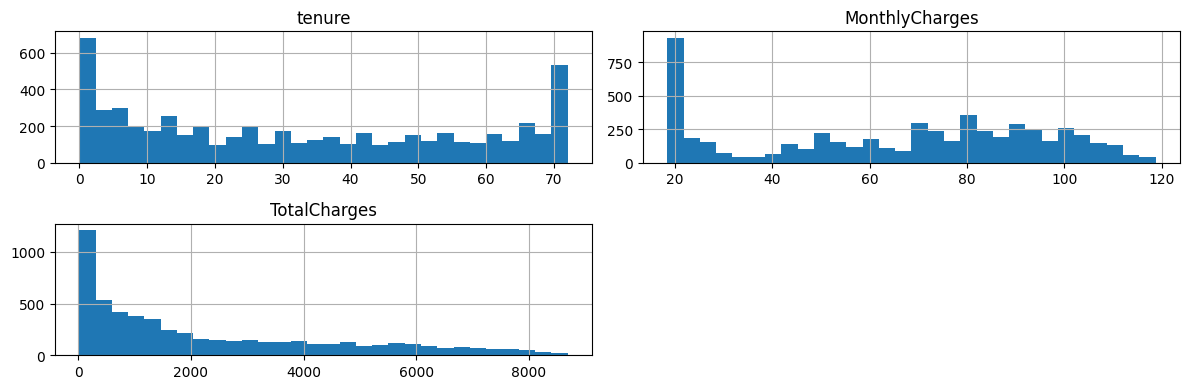

In [5]:
import matplotlib.pyplot as plt

# --- 1. Distribution of numeric features ---
explore[["tenure", "MonthlyCharges", "TotalCharges"]].hist(bins=30, figsize=(12, 4))
plt.tight_layout()
plt.show()

In [6]:
# --- 2. Correlation with Churn (temporary binary encoding, exploratory only) ---
explore["Churn_binary"] = (explore["Churn"] == "Yes").astype(int)

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "Churn_binary"]
corr_matrix = explore[numeric_cols].corr()
print(corr_matrix["Churn_binary"].sort_values(ascending=False))

Churn_binary      1.000000
MonthlyCharges    0.198040
TotalCharges     -0.194814
tenure           -0.345593
Name: Churn_binary, dtype: float64


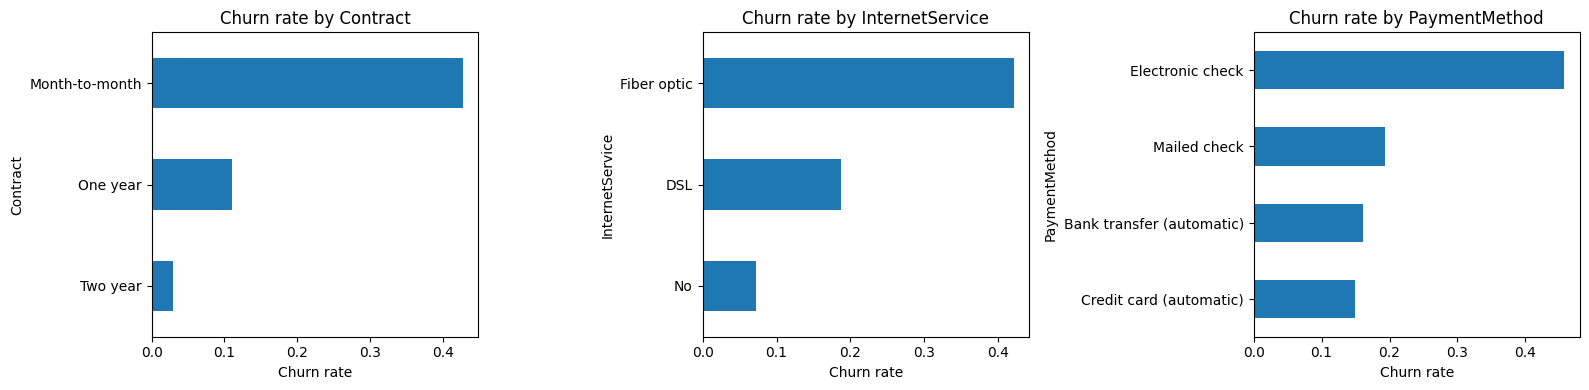

In [7]:
# --- 3. Churn rate by key categorical features ---
# This is where telco churn signal is usually strongest — contract length,
# internet service type, and payment method are classic high-signal fields.
categorical_checks = ["Contract", "InternetService", "PaymentMethod"]

fig, axes = plt.subplots(1, len(categorical_checks), figsize=(16, 4))
for ax, col in zip(axes, categorical_checks):
    explore.groupby(col)["Churn_binary"].mean().sort_values().plot(
        kind="barh", ax=ax, title=f"Churn rate by {col}"
    )
    ax.set_xlabel("Churn rate")
plt.tight_layout()
plt.show()

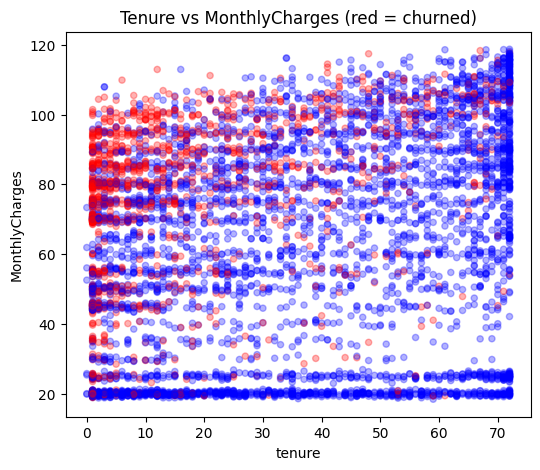

In [8]:
# --- 4. Tenure vs MonthlyCharges, colored by churn ---
# Useful for spotting whether churn clusters in a particular region
# (e.g. low-tenure + high-monthly-charges customers)
colors = explore["Churn"].map({"Yes": "red", "No": "blue"})
explore.plot(
    kind="scatter", x="tenure", y="MonthlyCharges",
    c=colors, alpha=0.3, figsize=(6, 5)
)
plt.title("Tenure vs MonthlyCharges (red = churned)")
plt.show()

In [9]:
# Separate features (X) from label (y), working only on train_set
# (test_set remains untouched)

X_train = train_set.drop(columns=["Churn", "customerID"])
y_train = train_set["Churn"]

print(X_train.shape, y_train.shape)
print(X_train.columns.tolist())

(5634, 19) (5634,)
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [10]:
from sklearn.impute import SimpleImputer

X_train = X_train.copy()

# Fix the dtype issue first: TotalCharges is a string with blanks for
# zero-tenure customers. Convert to numeric, blanks become real NaN.
X_train["TotalCharges"] = pd.to_numeric(X_train["TotalCharges"], errors="coerce")

# Capture the missing-value mask BEFORE imputing, so we can verify our
# domain assumption afterward (same discipline as your L0 assertion check
# in the earlier project)
missing_mask = X_train["TotalCharges"].isna()

print(f"Missing TotalCharges: {missing_mask.sum()}")
print(f"Missing tenure: {X_train['tenure'].isna().sum()}")
print(f"Missing MonthlyCharges: {X_train['MonthlyCharges'].isna().sum()}")

Missing TotalCharges: 8
Missing tenure: 0
Missing MonthlyCharges: 0


In [11]:
# Domain-informed imputation:
# - TotalCharges: missing == zero-tenure customer -> correct fill is 0,
#   not median (a brand-new customer genuinely has $0 total charges)
# - tenure / MonthlyCharges: no domain reason to deviate from the book's
#   generic median strategy (and these likely have no missing values in
#   this dataset anyway — but fitting the imputer here still matters,
#   since it protects against missing values showing up in test data or
#   at serving time later)

total_charges_imputer = SimpleImputer(strategy="constant", fill_value=0)
median_imputer = SimpleImputer(strategy="median")

X_train["TotalCharges"] = total_charges_imputer.fit_transform(X_train[["TotalCharges"]])
X_train[["tenure", "MonthlyCharges"]] = median_imputer.fit_transform(
    X_train[["tenure", "MonthlyCharges"]]
)

print(f"Missing TotalCharges after imputation: {X_train['TotalCharges'].isna().sum()}")

Missing TotalCharges after imputation: 0


In [12]:
# Verify the domain assumption holds: every row we filled with 0 should
# indeed be a zero-tenure customer — not some unrelated missing pattern
# we didn't account for
assert (X_train.loc[missing_mask, "tenure"] == 0).all(), \
    "Some imputed TotalCharges rows are NOT zero-tenure customers — domain assumption invalid!"

print(f"Assertion passed — all {missing_mask.sum()} imputed rows are zero-tenure customers.")

Assertion passed — all 8 imputed rows are zero-tenure customers.


In [13]:
from sklearn.preprocessing import OneHotEncoder

# Categorical (text) columns — everything except the numeric ones
# (tenure, MonthlyCharges, TotalCharges) and SeniorCitizen, which is
# already numeric 0/1 despite being a Yes/No-style field
categorical_cols = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod"
]

cat_encoder = OneHotEncoder(handle_unknown="ignore")
X_train_cat_encoded = cat_encoder.fit_transform(X_train[categorical_cols])

print(f"Original categorical columns: {len(categorical_cols)}")
print(f"Encoded shape: {X_train_cat_encoded.shape}")
print(f"\nExample — categories learned for 'Contract':")
print(cat_encoder.categories_[categorical_cols.index("Contract")])

Original categorical columns: 15
Encoded shape: (5634, 41)

Example — categories learned for 'Contract':
['Month-to-month' 'One year' 'Two year']


In [14]:
import numpy as np
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.pipeline import make_pipeline

# TotalCharges: long-tailed skew -> log-transform first, then scale
# (log1p, not log, since imputed zero-tenure rows are exactly 0)
log_pipeline = make_pipeline(
    FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
    StandardScaler()
)
total_charges_scaled = log_pipeline.fit_transform(X_train[["TotalCharges"]])

# tenure and MonthlyCharges: no long-tail skew observed -> plain scaling
plain_scaler = StandardScaler()
tenure_monthly_scaled = plain_scaler.fit_transform(X_train[["tenure", "MonthlyCharges"]])

print("TotalCharges (log + scaled) — mean/std:",
      total_charges_scaled.mean().round(3), total_charges_scaled.std().round(3))
print("tenure/MonthlyCharges (scaled) — mean/std per column:",
      tenure_monthly_scaled.mean(axis=0).round(3), tenure_monthly_scaled.std(axis=0).round(3))

TotalCharges (log + scaled) — mean/std: -0.0 1.0
tenure/MonthlyCharges (scaled) — mean/std per column: [-0. -0.] [1. 1.]


In [15]:
def charges_per_month_of_tenure(X):
    # X columns, in order: tenure, TotalCharges, MonthlyCharges
    tenure = X[:, 0]
    total_charges = X[:, 1]
    monthly_charges = X[:, 2]

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = total_charges / tenure

    # Zero-tenure customers have no billing history to divide by —
    # their MonthlyCharges rate is the best available estimate
    ratio = np.where(tenure == 0, monthly_charges, ratio)

    return ratio.reshape(-1, 1)


charges_ratio_transformer = FunctionTransformer(
    charges_per_month_of_tenure,
    feature_names_out=lambda transformer, input_features: ["charges_per_month_of_tenure"]
)

# Demo on the three relevant raw columns (still isolated — full integration
# happens in the ColumnTransformer at step 9)
demo_input = X_train[["tenure", "TotalCharges", "MonthlyCharges"]].to_numpy()
ratio_output = charges_ratio_transformer.fit_transform(demo_input)

print(f"Output shape: {ratio_output.shape}")
print(f"Any NaN/inf values: {not np.isfinite(ratio_output).all()}")
print(f"Sample values (first 5): {ratio_output[:5].ravel().round(2)}")
print(f"\nRatio for the 8 zero-tenure customers (should equal their MonthlyCharges):")
zero_tenure_mask = X_train["tenure"] == 0
print(ratio_output[zero_tenure_mask.to_numpy()].ravel())
print(X_train.loc[zero_tenure_mask, "MonthlyCharges"].to_numpy())

Output shape: (5634, 1)
Any NaN/inf values: False
Sample values (first 5): [48.62 76.77 45.41 73.3  44.55]

Ratio for the 8 zero-tenure customers (should equal their MonthlyCharges):
[73.35 20.   25.35 52.55 25.75 56.05 61.9  19.85]
[73.35 20.   25.35 52.55 25.75 56.05 61.9  19.85]


In [16]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer


# --- Helper: fix TotalCharges dtype (string -> float, blanks -> NaN) ---
# Needed independently in TWO branches below, since ColumnTransformer
# branches can't share intermediate results with each other.
def fix_total_charges_dtype(X):
    fixed = pd.to_numeric(np.asarray(X).ravel(), errors="coerce")
    return fixed.reshape(-1, 1)


# --- Helper: charges-per-month-of-tenure, updated for RAW input ---
# Unlike the step 8 version (which ran on already-cleaned X_train), this
# does its own TotalCharges dtype fix internally, since raw input arrives
# here as a string.
def charges_per_month_of_tenure_raw(X):
    X = np.asarray(X, dtype=object)
    tenure = X[:, 0].astype(float)
    total_charges = pd.to_numeric(X[:, 1], errors="coerce")
    monthly_charges = X[:, 2].astype(float)

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = total_charges / tenure

    # Zero-tenure customers: fall back to MonthlyCharges (same logic as step 8)
    ratio = np.where(tenure == 0, monthly_charges, ratio)
    return ratio.reshape(-1, 1)


# --- Sub-pipeline 1: tenure, MonthlyCharges -> median impute + scale ---
numeric_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

# --- Sub-pipeline 2: TotalCharges -> fix dtype, impute 0, log, scale ---
total_charges_pipeline = make_pipeline(
    FunctionTransformer(fix_total_charges_dtype, feature_names_out="one-to-one"),
    SimpleImputer(strategy="constant", fill_value=0),
    FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
    StandardScaler()
)

# --- Sub-pipeline 3: categorical -> one-hot ---
categorical_cols = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod"
]
categorical_pipeline = OneHotEncoder(handle_unknown="ignore")

# --- Sub-pipeline 4: custom ratio feature ---
ratio_pipeline = FunctionTransformer(
    charges_per_month_of_tenure_raw,
    feature_names_out=lambda transformer, input_features: ["charges_per_month_of_tenure"]
)

# --- Assemble the full ColumnTransformer ---
# SeniorCitizen is already numeric 0/1 -> passthrough, no transform needed
preprocessing = ColumnTransformer([
    ("numeric", numeric_pipeline, ["tenure", "MonthlyCharges"]),
    ("total_charges", total_charges_pipeline, ["TotalCharges"]),
    ("categorical", categorical_pipeline, categorical_cols),
    ("ratio", ratio_pipeline, ["tenure", "TotalCharges", "MonthlyCharges"]),
], remainder="passthrough")

In [17]:
# --- Test on a FRESH, untouched raw slice — not the mutated X_train ---
X_train_raw = train_set.drop(columns=["Churn", "customerID"])

X_train_prepared = preprocessing.fit_transform(X_train_raw)

print(f"Input shape:  {X_train_raw.shape}")
print(f"Output shape: {X_train_prepared.shape}")
print(f"Output type:  {type(X_train_prepared)}")

# Sanity checks
dense = X_train_prepared.toarray() if hasattr(X_train_prepared, "toarray") else X_train_prepared
print(f"Any NaN: {np.isnan(dense).any()}")
print(f"Any inf: {np.isinf(dense).any()}")

Input shape:  (5634, 19)
Output shape: (5634, 46)
Output type:  <class 'numpy.ndarray'>
Any NaN: False
Any inf: False


In [18]:
# Verify the zero-tenure fallback still works correctly starting from
# genuinely raw (string) TotalCharges — this is the real proof the
# pipeline doesn't secretly depend on our earlier manual cleaning
feature_names = preprocessing.get_feature_names_out()
ratio_col_idx = list(feature_names).index("ratio__charges_per_month_of_tenure")

zero_tenure_mask = (X_train_raw["tenure"] == 0).to_numpy()
print("Ratio values for zero-tenure customers (from raw pipeline):")
print(dense[zero_tenure_mask, ratio_col_idx])
print("Their MonthlyCharges (should match exactly):")
print(X_train_raw.loc[zero_tenure_mask, "MonthlyCharges"].to_numpy())

Ratio values for zero-tenure customers (from raw pipeline):
[73.35 20.   25.35 52.55 25.75 56.05 61.9  19.85]
Their MonthlyCharges (should match exactly):
[73.35 20.   25.35 52.55 25.75 56.05 61.9  19.85]


In [19]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

# Stratified folds — preserves the ~73/27 churn ratio in every fold,
# same reasoning as the stratified train/test split back in step 2
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
}

results = []

for name, model in candidates.items():
    full_pipeline = make_pipeline(preprocessing, model)

    scores = cross_validate(
        full_pipeline, X_train_raw, y_train,
        cv=cv,
        scoring=["roc_auc", "accuracy"],
        n_jobs=-1
    )

    results.append({
        "model": name,
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "roc_auc_std": scores["test_roc_auc"].std(),
        "accuracy_mean": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
    })

results_df = pd.DataFrame(results).sort_values("roc_auc_mean", ascending=False)
print(results_df.to_string(index=False))

              model  roc_auc_mean  roc_auc_std  accuracy_mean  accuracy_std
Logistic Regression      0.849299     0.011393       0.807066      0.012423
      Random Forest      0.822080     0.008721       0.788073      0.005779
      Decision Tree      0.658138     0.021727       0.729501      0.015714


In [20]:
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier

# Build the pipeline once, then inspect its step names —
# don't guess the prefix, verify it
rf_pipeline = make_pipeline(preprocessing, RandomForestClassifier(random_state=42))
print(rf_pipeline.named_steps.keys())

dict_keys(['columntransformer', 'randomforestclassifier'])


In [21]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_distributions = {
    "randomforestclassifier__n_estimators": randint(100, 500),
    "randomforestclassifier__max_depth": randint(3, 20),
    "randomforestclassifier__min_samples_split": randint(2, 20),
    "randomforestclassifier__min_samples_leaf": randint(1, 10),
    "randomforestclassifier__max_features": uniform(0.1, 0.9),  # sampled as a fraction of total features
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

rf_search.fit(X_train_raw, y_train)

print(f"Best ROC-AUC (cross-validated): {rf_search.best_score_:.4f}")
print(f"Best hyperparameters: {rf_search.best_params_}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best ROC-AUC (cross-validated): 0.8461
Best hyperparameters: {'randomforestclassifier__max_depth': 5, 'randomforestclassifier__max_features': np.float64(0.8739463660626885), 'randomforestclassifier__min_samples_leaf': 7, 'randomforestclassifier__min_samples_split': 10, 'randomforestclassifier__n_estimators': 266}
